In [2]:
#importing the necessary libraries
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

import nltk

import seaborn as sns

from nltk.corpus import stopwords

import string

from nltk.stem import PorterStemmer

from wordcloud import WordCloud

from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

In [3]:
#reading the CSV file
x = pd.read_csv("sms-spam.csv")
e = pd.read_csv("emails.csv")
#displaying the dataframe
x
e

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [4]:
#dataset size - 5572 rows x 5 columns
x.shape

(5572, 5)

## Data Cleaning

In [15]:
#printing the concise summary of the dataset
x.info()

<class 'pandas.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5169 non-null   int64
 1   text    5169 non-null   str  
dtypes: int64(1), str(1)
memory usage: 521.6 KB


In [5]:
#column 2, 3, 4 have majority missing values, so it is better to drop them.
x.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

#displaying the edited dataframe
x

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [8]:
print(e['label'].unique())

[1 0]


In [6]:
x = pd.read_csv("sms-spam.csv")

x = x[['v1','v2']]
x.columns = ['label','text']

x['label'] = x['label'].map({
    'ham':0,
    'spam':1
})

print(x.head())

   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [7]:
e = e[['text','spam']]
e.columns = ['text','label']

e = e[['label','text']]

print(e.head())

   label                                               text
0      1  Subject: naturally irresistible your corporate...
1      1  Subject: the stock trading gunslinger  fanny i...
2      1  Subject: unbelievable new homes made easy  im ...
3      1  Subject: 4 color printing special  request add...
4      1  Subject: do not have money , get software cds ...


In [15]:
df = pd.concat([x,e],ignore_index=True)

print(df.head())
print(df.shape)

   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
(10864, 2)


In [16]:
extra = [
["Limited Time Offer Buy now and get 90 percent OFF",1],
["URGENT! Your account has been suspended",1],
["Claim your reward now",1],
["Your bank account will be blocked. Verify immediately",1],
["Congratulations you won free iphone",1],
["Exclusive deal click now",1],
["Urgent account verification required",1],
["Meeting agenda attached",0],
["Project update for tomorrow",0]
]

extra_df = pd.DataFrame(
    extra,
    columns=["text","label"]
)

df = pd.concat(
    [df, extra_df],
    ignore_index=True
)

In [9]:
#result has categorical labels, we need to convert it into numerical values - enbcoding
#for that we will be using 'LabelEncoder' from sklearn

In [11]:
#so 0 means no SPAM, 1 means SPAM

In [7]:
#check if there is any NULL value
x.isnull().sum()

label    0
text     0
dtype: int64

In [29]:
#the dataset has NO null values, so don't need to handle them

In [8]:
#check if there is any DUPLICATE values
x.duplicated().sum()

np.int64(403)

In [9]:
#check if there is any DUPLICATE values
e.duplicated().sum()

np.int64(33)

In [10]:
x.drop_duplicates(inplace=True)

In [11]:
e.drop_duplicates(inplace=True)

In [12]:
print(x.columns)
print(x.head())

Index(['label', 'text'], dtype='str')
   label                                               text
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [16]:
#rows reduced from 5572 to 5169 after DUPLICATED values have been deleted

## EDA - Exploratory Data Analysis

In [17]:
#the given problem is a classification problem, so we need to understand the data first by performing EDA.
#the dataset has only 2 columns, so less analysis required.

In [19]:
#out of 5169 datavalues, 653 are SPAM

In [14]:
653*100.0/5169

12.633004449603405

In [21]:
#12.63% is SPAM and 87.37% is not SPAM

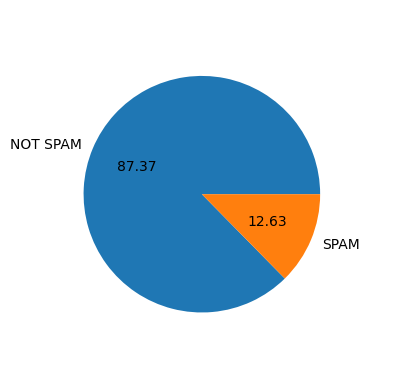

In [16]:
#for better representation, we can use PIE CHART to represent it.
#PIE CHARTS can be created using matplotlib library

plt.pie(x['label'].value_counts(),  labels = ['NOT SPAM', 'SPAM'], autopct = '%0.2f', radius = 0.8)
plt.show()

In [23]:
#hence, highly IMBALANCED DATA

In [24]:
#now we will be analysing the number of alphabets/words/sentences being used in the TEXT
#for this, will create 3 new columns: (1) no. of characters (2) no. of words (3) no. of sentences in SMS

#using 'nltk' library for this. 
#Natural Language Toolkit for text processing 
#(pip install nltk)

In [20]:
#downloading the dependencies 
#punkt package includes pre-trained models for tokenizing text in many languages

nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [23]:
#creating a new column with count of characters
x['countCharacters'] = x['text'].apply(len)

#creating a new column with count of words
x['countWords'] = x['text'].apply(lambda i:len(nltk.word_tokenize(i)))
#'word_tokenize' function takes a string of text as input and returns a list of words

#creating a new column with count of sentences
x['countSentences'] = x['text'].apply(lambda i:len(nltk.sent_tokenize(i)))
#'sent_tokenize' function takes a string of text as input and returns a list of sentences

In [21]:
#displaying the edited dataframe with the 3 new columns added
x.head()

,label,text,countCharacters,countWords,countSentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [24]:
#extracting the 5 number summary of the 3 new column values
x[['countCharacters', 'countWords', 'countSentences']].describe()

,countCharacters,countWords,countSentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
#extracting the same summaries, classified on the basis of SPAM and not SPAM

In [22]:
#for not SPAM
x[x['label'] == 0][['countCharacters', 'countWords', 'countSentences']].describe()

,countCharacters,countWords,countSentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [25]:
#for SPAM
x[x['label'] == 1][['countCharacters', 'countWords', 'countSentences']].describe()

,countCharacters,countWords,countSentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<AxesSubplot:xlabel='countCharacters', ylabel='Count'>

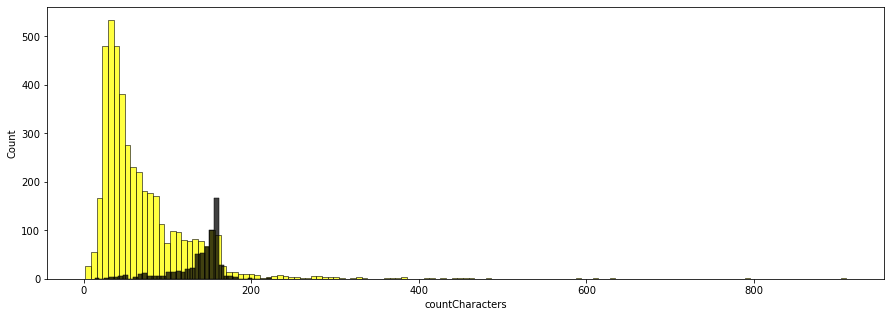

In [ ]:
#for better visualization, we will plot a histogram using 'seaborn'
plt.figure(figsize = (15, 5))
sns.histplot(x[x['label'] == 0]['countCharacters'], color = "yellow")
sns.histplot(x[x['label'] == 1]['countCharacters'], color = "black")

#black -> SPAM, yellow -> not SPAM

<AxesSubplot:xlabel='countWords', ylabel='Count'>

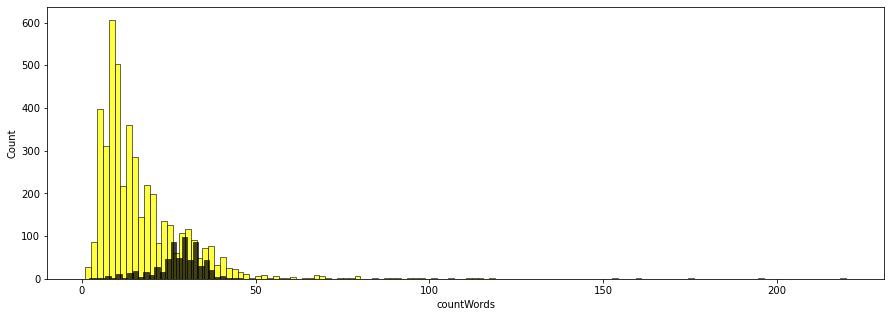

In [ ]:
plt.figure(figsize = (15, 5))
sns.histplot(x[x['label'] == 0]['countWords'], color = "yellow")
sns.histplot(x[x['label'] == 1]['countWords'], color = "black")

#black -> SPAM, yellow -> not SPAM

In [ ]:
#observation : SPAM messages have more no of characters used, mean is 137.89 for SPAM and 70.45 for not SPAM

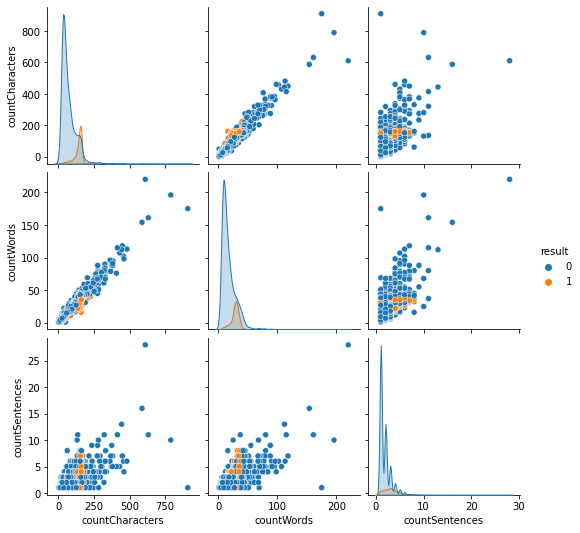

In [ ]:
#finding relationship between the columns
sns.pairplot(x, hue='label')

In [ ]:
#find pearson's correlation coefficient
x.corr()

,result,countCharacters,countWords,countSentences
result,1.000000,0.384717,0.262984,0.284901
countCharacters,0.384717,1.000000,0.965770,0.638143
countWords,0.262984,0.965770,1.000000,0.684541
countSentences,0.284901,0.638143,0.684541,1.000000


<AxesSubplot:>

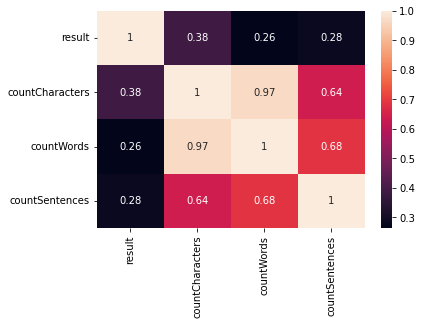

In [ ]:
#converting it into a heatmap
sns.heatmap(x.corr(), annot=True)

In [ ]:
#multi-collinearity in the dataset
#all new 3 columns are highly correlated with each other but countCharacters is correlated more with the 'result' than any other column

## Data Preprocessing

In [ ]:
#peforming preprocessing such as tokenization (converting the text into tokens or words), removing special characters,
#removing stop words and punctuation and finallying stemming the data.
#also, converting to lower case first and then pre-processing the data

In [25]:
#downloading the package which contains the stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [28]:
def transform_text(text):

    text = text.lower()
    text = nltk.word_tokenize(text)

    removedSC = []

    for i in text:
        if i.isalnum():
            removedSC.append(i)

    removedSWPC = []

    for i in removedSC:
        if i not in stop_words and i not in string.punctuation:
            removedSWPC.append(i)

    stemmed = []

    for i in removedSWPC:
        stemmed.append(ps.stem(i))

    return " ".join(stemmed)

In [29]:
df['transformed_text'] = df['text'].apply(transform_text)

In [ ]:
#function for transforming the text is ready

In [ ]:
# #will create a new column to store the transformed text -> 'processed'
# x['processed'] = x['input'].apply(transform_text)

# #displaying the edited dataframe with a new column 'processed'
# x.head()

C:\Users\codes\AppData\Local\Temp\ipykernel_37516\2432381459.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['processed'] = x['input'].apply(transform_text)


,result,input,countCharacters,countWords,countSentences,processed
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [29]:
#will be creating word cloud for data visualization to display the most frequently occurring words in the processed dataset.
#using 'WordCloud' class

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [75]:
spamWC = wc.generate(
    df[df['label'] == 1]['transformed_text'].str.cat(sep=" ")
)

nonSpamWC = wc.generate(
    df[df['label'] == 0]['transformed_text'].str.cat(sep=" ")
)

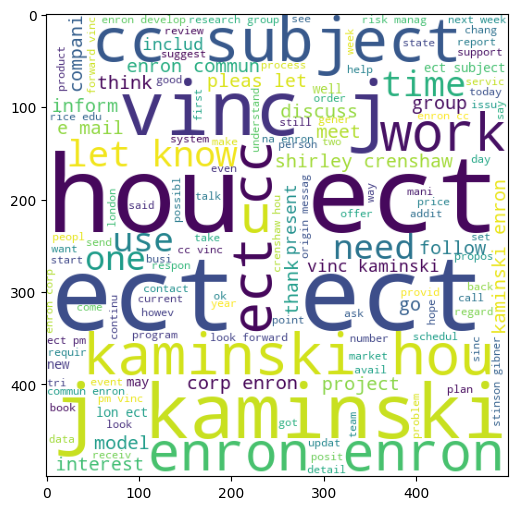

In [76]:

plt.figure(figsize=(12, 6))
plt.imshow(spamWC)

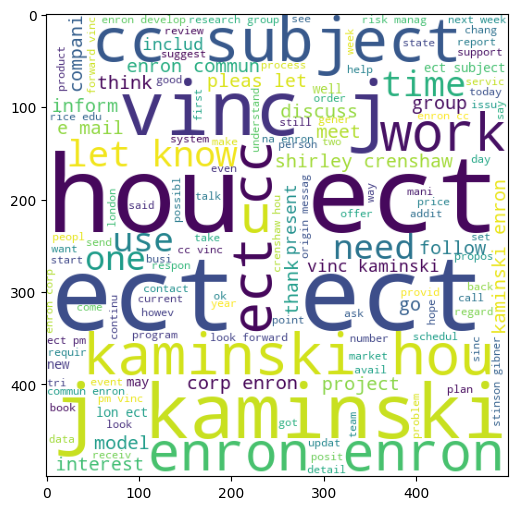

In [77]:
plt.figure(figsize=(12, 6))
plt.imshow(nonSpamWC)

In [ ]:
#extracting the most common words used in both SPAM and not SPAM messages

In [78]:
# extracting all words used in spam messages

spamWords = []

for msg in df[df['label'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spamWords.append(word)

spamWords

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

In [79]:
hamWords = []

for msg in df[df['label'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        hamWords.append(word)

hamWords

['go',
 'jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat',
 'ok',
 'lar',
 'joke',
 'wif',
 'u',
 'oni',
 'u',
 'dun',
 'say',
 'earli',
 'hor',
 'u',
 'c',
 'alreadi',
 'say',
 'nah',
 'think',
 'goe',
 'usf',
 'live',
 'around',
 'though',
 'even',
 'brother',
 'like',
 'speak',
 'treat',
 'like',
 'aid',
 'patent',
 'per',
 'request',
 'mell',
 'oru',
 'minnaminungint',
 'nurungu',
 'vettam',
 'set',
 'callertun',
 'caller',
 'press',
 '9',
 'copi',
 'friend',
 'callertun',
 'gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today',
 'search',
 'right',
 'word',
 'thank',
 'breather',
 'promis',
 'wont',
 'take',
 'help',
 'grant',
 'fulfil',
 'promis',
 'wonder',
 'bless',
 'time',
 'date',
 'sunday',
 'oh',
 'k',
 'watch',
 'eh',
 'u',
 'rememb',
 '2',
 'spell',
 'name',
 'ye',
 'v',
 'naughti',
 'make',
 'v',
 'wet',
 'fine',
 'thatåõ',
 'wa

In [41]:
#to count the frequency of the words, we will be using the Counter class to create a dictionary
spamWordsDictionary = Counter(spamWords)

#to extract the most common words
spamWordsDictionary.most_common(40)

[('subject', 1578),
 ('compani', 1068),
 ('com', 1000),
 ('1', 980),
 ('mail', 917),
 ('busi', 899),
 ('email', 867),
 ('inform', 827),
 ('free', 797),
 ('2', 768),
 ('get', 768),
 ('receiv', 758),
 ('e', 702),
 ('5', 695),
 ('pleas', 670),
 ('money', 666),
 ('3', 624),
 ('http', 621),
 ('make', 614),
 ('time', 611),
 ('one', 602),
 ('market', 601),
 ('new', 568),
 ('offer', 561),
 ('000', 560),
 ('use', 558),
 ('order', 558),
 ('click', 557),
 ('us', 544),
 ('invest', 540),
 ('secur', 521),
 ('price', 518),
 ('call', 510),
 ('websit', 507),
 ('report', 507),
 ('list', 503),
 ('may', 495),
 ('messag', 487),
 ('address', 464),
 ('adob', 462)]

In [42]:
#converting this dictionary to a dataframe
mostCommonSPAM = pd.DataFrame(spamWordsDictionary.most_common(40))

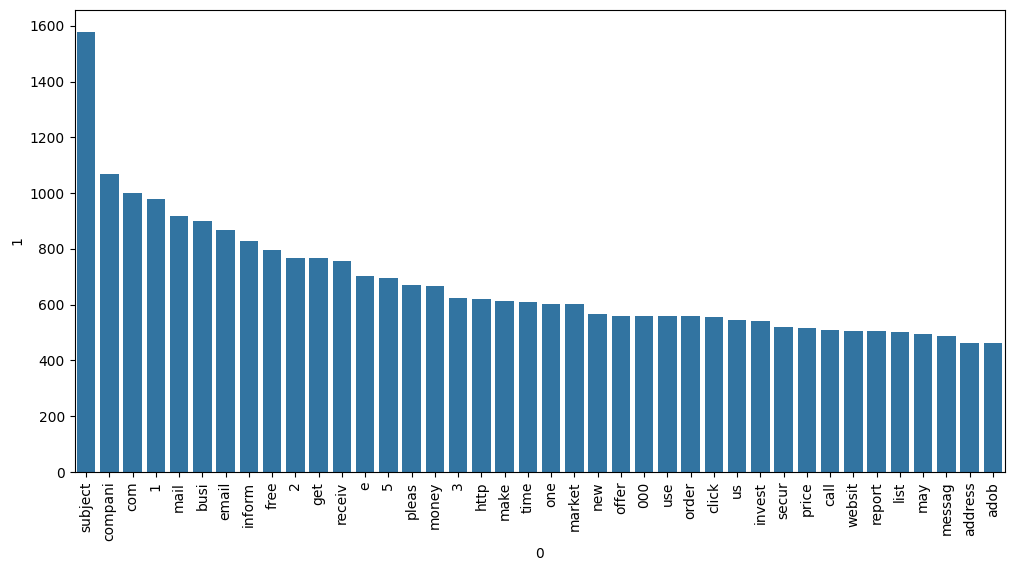

In [43]:
#plotting a bar plot of the mostCommonSPAM dataframe
plt.figure(figsize=(12, 6))
sns.barplot(data = mostCommonSPAM, x=0, y=1)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
#words like 'CALL', 'FREE', '2', 'TXT', 'TEXT', 'UR', 'MOBIL' are the most common words in SPAM texts

## Model Building

In [ ]:
#NaiveBayes classifier works BEST on textual data, so will firstly perform it on the dataset.

In [ ]:
#we need to give numerical inputs to the classifier model, so will have to convert the 'processed' column into vectors.
#using 'bag of words'

In [44]:
#converting the collection of text into a matrix of token counts
cv = CountVectorizer()

In [ ]:
# ==========================
# TF-IDF Vectorization
# ==========================

# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(
#     max_features=5000,
#     ngram_range=(1,2)
# )

X = cv.fit_transform(df['transformed_text'])
y = df['label']

In [33]:
#splitting the training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 49)

In [34]:
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
# #training the dataset for GaussianNB
# gnb.fit(X_train, y_train)
# y_pred1 = gnb.predict(X_test)
# print(accuracy_score(y_test, y_pred1))
# print(confusion_matrix(y_test, y_pred1))
# print(precision_score(y_test, y_pred1))

0.7791072250345145
[[1347  433]
 [  47  346]]
0.4441591784338896


In [49]:
#training the dataset for MultinomialnNB
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9162448228255867
[[1604  176]
 [   6  387]]
0.6873889875666075


In [50]:
#training the dataset for BernoulliNB
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9185457892314772
[[1749   31]
 [ 146  247]]
0.8884892086330936


In [ ]:
#we have to focus mainly on 'precision' value
#the max precision we got is 9.45 with 9.64 as accuracy

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
#using 'TfidfVectorizer' for vectorization 
tfidf = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,2)
)


#transforming the data of processed column
X = tfidf.fit_transform(df['transformed_text'])

#storing the values of the 'result' column
y = df['label']

#splitting the training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 49)

In [35]:
#training the dataset for MultinomialnNB
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9622988505747126
[[1750   11]
 [  71  343]]
0.9689265536723164


In [36]:
#training the dataset for BernoulliNB
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.96
[[1743   18]
 [  69  345]]
0.9504132231404959


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score


lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred_lr))
print("Precision:", precision_score(y_test,pred_lr))
print("Recall:", recall_score(y_test,pred_lr))

Accuracy: 0.96
Precision: 0.9766763848396501
Recall: 0.8091787439613527


In [ ]:
# #trying out different CLASSIFIER model for the BEST predictions
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import AdaBoostClassifier
# from sklearn.ensemble import BaggingClassifier
# from sklearn.ensemble import ExtraTreesClassifier
# from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# #creating objects of the classifier models
# svc = SVC(kernel='sigmoid', gamma=1.0)
# knc = KNeighborsClassifier()
# mnb = MultinomialNB()
# dtc = DecisionTreeClassifier(max_depth=5)
# lrc = LogisticRegression(solver='liblinear', penalty='l1')
# rfc = RandomForestClassifier(n_estimators=50, random_state=2)
# abc = AdaBoostClassifier(n_estimators=50, random_state=2)
# bc = BaggingClassifier(n_estimators=50, random_state=2)
# etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
# gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)

In [ ]:
#precision is 1, we need to maximize the accuracy score.
#try using the Voting classifier

In [38]:
#Voting classifier of NB, RF and ETC

#creating the objects for the classifier classes
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier

mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

lr = LogisticRegression(max_iter=1000)

In [39]:
rfc.fit(X_train, y_train)

pred_rfc = rfc.predict(X_test)

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, pred_rfc))
print("Precision:", precision_score(y_test, pred_rfc))
print("Recall   :", recall_score(y_test, pred_rfc))

Random Forest
Accuracy : 0.9645977011494253
Precision: 0.9667590027700831
Recall   : 0.8429951690821256


In [40]:
etc.fit(X_train, y_train)

pred_etc = etc.predict(X_test)

print("Extra Trees")
print("Accuracy :", accuracy_score(y_test, pred_etc))
print("Precision:", precision_score(y_test, pred_etc))
print("Recall   :", recall_score(y_test, pred_etc))

Extra Trees
Accuracy : 0.9668965517241379
Precision: 0.975
Recall   : 0.8478260869565217


In [41]:
#creating voting object
from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators=[('rf', rfc), ('nb', mnb), ('et', etc)],voting='soft')

In [42]:
#training the data
voting.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[RandomForestC...andom_state=2), MultinomialNB(), ExtraTreesCla...andom_state=2)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,7000


In [43]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test, y_pred))

Accuracy 0.9728735632183908
Precision 0.9944289693593314
Recall   : 0.8623188405797102


In [ ]:
#precision is still 1 but accuracy dropped down.

In [ ]:
#let's try STACKING

In [44]:
#Stacking of NB, RF and ETC
estimators=[('rf', rfc), ('nb', mnb), ('et', etc)]

#most weightage to ETC
final_estimator=ExtraTreesClassifier()

In [45]:
from sklearn.ensemble import StackingClassifier
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [46]:
#training the dataset
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

#printing the scores
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test, y_pred))

Accuracy 0.9710344827586207
Precision 0.9333333333333333
Recall   : 0.9130434782608695


In [ ]:
#finally, Voting Classifier is giving the best results, so we will be using the Voting classifier.

In [ ]:
#model is PREPARED.
#now we have to host the website, for that pipeling needs to be done
#the text which we will get, has to be transformed first, then vectorized and then apply the algorithm

In [47]:
model = voting

import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))